# Experiments with hierarchical structure of text content

In [2]:
# This Chris' code processes OCR (Optical Character Recognition) data to build a hierarchical structure of text content.

# The is_heading() function determines if a line of text is a heading by checking if it:
# 1. Ends with a colon (common in forms)
# 2. Has a high ratio of uppercase letters (>60% excluding punctuation)

# The overlaps_style() function checks if a line's text (defined by offset and length) 
# overlaps with any style spans in the document. This is used to detect formatting.

# The is_line_handwritten() function uses overlaps_style() to check if a line matches
# any handwritten text styles defined in the document metadata.

# The main parse_ocr_into_hierarchy() function:
# 1. Takes OCR data containing paragraphs with text content, bounding boxes, and styles
# 2. Extracts lines of text with their vertical position (y-coordinate) and metadata
# 3. Sorts lines from top to bottom
# 4. Groups the lines into a hierarchy where:
#    - Lines detected as headings start new sections
#    - Other lines are grouped under the most recent heading
#    - Lines with no preceding heading go under a "Misc" section
# 5. For each line, checks if it's handwritten and includes that in the metadata
# 6. Returns a list of sections, each with:
#    - A heading
#    - A list of lines with their text and handwriting status

# The hierarchy helps preserve the document's logical structure and formatting,
# making it easier to analyze or display the content while maintaining its organization.

import json
import re

def is_heading(text):
    """
    A simple heading heuristic:
      - ends with ':' (common in forms), OR
      - mostly uppercase, or all uppercase (minus punctuation).
    Adjust to your preference.
    """
    # Quick check if ends with colon:
    if text.strip().endswith(":"):
        return True
    
    # Remove punctuation for uppercase ratio
    stripped = re.sub(r"[^A-Za-z]", "", text)
    if not stripped:
        return False
    
    uppercase_count = sum(ch.isupper() for ch in stripped)
    ratio = uppercase_count / len(stripped)
    return (ratio > 0.6)

def overlaps_style(line_offset, line_length, style_spans):
    """
    Returns True if any style span overlaps with the line offset/length.
    """
    start = line_offset
    end = line_offset + line_length
    for s in style_spans:
        s_start = s["offset"]
        s_end = s["offset"] + s["length"]
        # If they overlap, return True
        if  (s_start == start and s_end == end):
            #print(f"Styles {s_start}, {s_end}, {start}, {end}")
            return True
    return False

def is_line_handwritten(line_offset, line_length, styles):
    """
    Checks if (offset, length) overlaps with any style that has is_handwritten=True.
    """
    for style in styles:
        if style.get("is_handwritten"):
            # for each 'spans' in style
            if overlaps_style(line_offset, line_length, style.get("spans", [])):
                return True
    return False

def parse_ocr_into_hierarchy(ocr_data):
    # Grab the top-level styles for handwriting detection
    styles = ocr_data.get("styles", [])
    #print(styles)
    # The paragraphs list has the 'content', bounding regions, etc.
    paragraphs = ocr_data.get("paragraphs", [])

    # Build a list of (approx_y, text, offset, length, polygon)
    lines_info = []
    for p in paragraphs:
        # Some paragraphs might be missing bounding info
        if not p["bounding_regions"]:
            continue
        # Approximate Y from the first bounding region polygon
        # Usually you'd pick minY to get the top
        region = p["bounding_regions"][0]
        poly = region["polygon"]
        approx_y = min(pt["y"] for pt in poly)

        # We'll assume a single span for the entire paragraph
        if p["spans"]:
            offset = p["spans"][0]["offset"]
            length = p["spans"][0]["length"]
        else:
            offset = 0
            length = len(p["content"])

        lines_info.append({
            "y": approx_y,
            "text": p["content"],
            "offset": offset,
            "length": length,
            "polygon": poly,
        })

    # Sort lines top-to-bottom
    lines_info.sort(key=lambda x: x["y"])

    # We'll store a list of sections: { heading: "XYZ", lines: [...] }
    # If a line is recognized as heading, start a new section
    # Otherwise append to the current section's lines
    hierarchy = []
    current_section = None

    for line in lines_info:
        text = line["text"]
        if is_heading(text):
            # Start a new heading section
            new_heading = {
                "heading": text,
                #"bounding_box": line["polygon"],
                "lines": []
            }
            hierarchy.append(new_heading)
            current_section = new_heading
        else:
            # If we have no current heading, create a default "Misc"
            if not current_section:
                current_section = {
                    "heading": "Misc",
                    "lines": []
                }
                hierarchy.append(current_section)

            # Check if line is handwritten
            line_handwritten = is_line_handwritten(
                line["offset"], line["length"], styles
            )

            # current_section["lines"].append({
            #     "text": text,
            #     #"bounding_box": line["polygon"],
            #     #"is_handwritten": line_handwritten
            # })

            if line_handwritten:
                current_section["lines"].append({
                    "text": text,
                    #"bounding_box": line["polygon"],
                    "is_handwritten": line_handwritten
                })
            else:
                current_section["lines"].append({
                    "text": text,
                    #"bounding_box": line["polygon"],
                    #"is_handwritten": line_handwritten
                })


    return hierarchy

# Multi=column documents
def find_min_xy(paragraph):
    """
    Return (x_min, y_min) from a paragraph's first bounding region's polygon.
    If there are multiple bounding regions, adapt as needed.
    """
    if not paragraph["bounding_regions"]:
        return (999999, 999999)  # fallback

    poly = paragraph["bounding_regions"][0]["polygon"]
    xs = [pt["x"] for pt in poly]
    ys = [pt["y"] for pt in poly]
    return (min(xs), min(ys))


def cluster_into_columns(lines_info, col_gap=50):
    """
    A simplistic approach to group lines into columns:
      1) Sort by x_min.
      2) Accumulate lines into a 'current column' if the line’s x_min
         is not too far from the column’s average x.
      3) If the gap is large, start a new column.

    Returns a list of columns, each a list of lines_info dicts.
    """

    # Sort lines by x_min
    lines_sorted = sorted(lines_info, key=lambda x: x["x_min"])

    columns = []
    for line in lines_sorted:
        x = line["x_min"]

        # Try to place in an existing column
        placed = False
        for col in columns:
            # Heuristic: Compare this line’s x with the average x of that column
            avg_x = sum(ln["x_min"] for ln in col) / len(col)
            if abs(x - avg_x) < col_gap:
                col.append(line)
                placed = True
                break

        if not placed:
            # Start a new column
            columns.append([line])

    return columns


def parse_ocr_into_hierarchy_with_columns(ocr_data, col_gap=50):
    """
    1. Gather paragraphs from OCR.
    2. Compute x_min, y_min per paragraph => lines_info.
    3. Cluster lines_info into columns via 'cluster_into_columns()'.
    4. Sort each column top->bottom by y_min.
    5. Read columns left->right or produce final order.
    6. Then do heading-based grouping or any other hierarchy logic.
    """

    # Grab the top-level styles for handwriting detection
    styles = ocr_data.get("styles", [])

    paragraphs = ocr_data.get("paragraphs", [])
    lines_info = []

    for p in paragraphs:
        if not p["bounding_regions"]:
            continue

        (x_min, y_min) = find_min_xy(p)

        # We'll assume a single span for the entire paragraph
        offset = p["spans"][0]["offset"] if p["spans"] else 0
        length = p["spans"][0]["length"] if p["spans"] else len(p["content"])

        lines_info.append({
            "x_min": x_min,
            "y_min": y_min,
            "text": p["content"],
            "offset": offset,
            "length": length,
            "polygon": p["bounding_regions"][0]["polygon"],
        })

    # 1) Cluster columns
    columns = cluster_into_columns(lines_info, col_gap=col_gap)

    # 2) Sort columns themselves by the average x_min (left -> right)
    columns_with_avg = []
    for col in columns:
        avg_x = sum(line["x_min"] for line in col) / len(col)
        columns_with_avg.append((avg_x, col))

    columns_sorted = sorted(columns_with_avg, key=lambda c: c[0])

    # 3) For each column, sort lines top->bottom
    #    Then flatten them in that order if you want a single reading flow.
    final_lines_order = []
    for avg_x, col in columns_sorted:
        # sort top->bottom by y_min
        col_sorted = sorted(col, key=lambda ln: ln["y_min"])
        final_lines_order.extend(col_sorted)

    # 4) Now final_lines_order is a single, left->right, top->bottom sequence
    #    We can pass into your heading logic from the question:

    # Example: do the heading-based grouping
    # (Same approach from your parse_ocr_into_hierarchy function, but now we already have a sorted list.)
    return build_heading_hierarchy(final_lines_order, styles=styles)


def build_heading_hierarchy(sorted_lines, styles):
    """
    Example minimal version of your heading-based grouping.
    We assume lines are sorted in reading order already.
    """
    hierarchy = []
    current_section = None

    for line in sorted_lines:
        text = line["text"]
        # check if heading
        if is_heading(text):
            new_heading = {
                "heading": text,
                "lines": []
            }
            hierarchy.append(new_heading)
            current_section = new_heading
        else:
            if not current_section:
                current_section = {
                    "heading": "Misc",
                    "lines": []
                }
                hierarchy.append(current_section)

            # Check if line is handwritten
            line_handwritten = is_line_handwritten(line["offset"], line["length"], styles)

            # append line
            current_section["lines"].append({
                "text": text,
                "is_handwritten": line_handwritten
            })

    return hierarchy


# You can reuse your existing is_heading, is_line_handwritten, etc.:
def is_heading(text):
    """
    Very naive heading check:
    """
    if text.strip().endswith(":"):
        return True

    stripped = re.sub(r"[^A-Za-z]", "", text)
    if not stripped:
        return False

    uppercase_count = sum(ch.isupper() for ch in stripped)
    ratio = uppercase_count / len(stripped)
    return (ratio > 0.6)

def is_line_handwritten(line_offset, line_length, styles):
    """
    Same approach you provided. Just reusing for completeness.
    """
    for style in styles:
        if style.get("is_handwritten"):
            if overlaps_style(line_offset, line_length, style.get("spans", [])):
                return True
    return False

def overlaps_style(line_offset, line_length, style_spans):
    start = line_offset
    end = line_offset + line_length
    for s in style_spans:
        s_start = s["offset"]
        s_end = s["offset"] + s["length"]
        # check overlap
        if s_start == start and s_end == end:
            return True
    return False


# 1. Load your OCR JSON
ocr_filename  = '../datasets/FUNSD/training_data/annotations_azure_model__prebuilt_read/0001463282.json'

with open(ocr_filename, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

# 2. Parse into hierarchical structure
#doc_structure = parse_ocr_into_hierarchy(ocr_data)
doc_structure = parse_ocr_into_hierarchy_with_columns(ocr_data)

# 3. Print or use the result
print(json.dumps(doc_structure, indent=2))

[
  {
    "heading": "Misc",
    "lines": [
      {
        "text": "Date: 4/16/90",
        "is_handwritten": false
      },
      {
        "text": "Description: Y-1 Ultra 100's_vs. Winston Ultra 100's",
        "is_handwritten": false
      },
      {
        "text": "Requested By: W. T. Carpenter",
        "is_handwritten": false
      }
    ]
  },
  {
    "heading": "Competitive Proposals Obtained:",
    "lines": [
      {
        "text": "Supplier",
        "is_handwritten": false
      },
      {
        "text": "Kapuler",
        "is_handwritten": false
      },
      {
        "text": "Market Facts",
        "is_handwritten": false
      }
    ]
  },
  {
    "heading": "PROJECTED:",
    "lines": [
      {
        "text": "Internal Init. Date",
        "is_handwritten": false
      },
      {
        "text": "Ext. Auth. Date",
        "is_handwritten": false
      },
      {
        "text": "Wave(s)",
        "is_handwritten": false
      },
      {
        "text": "Field Compl

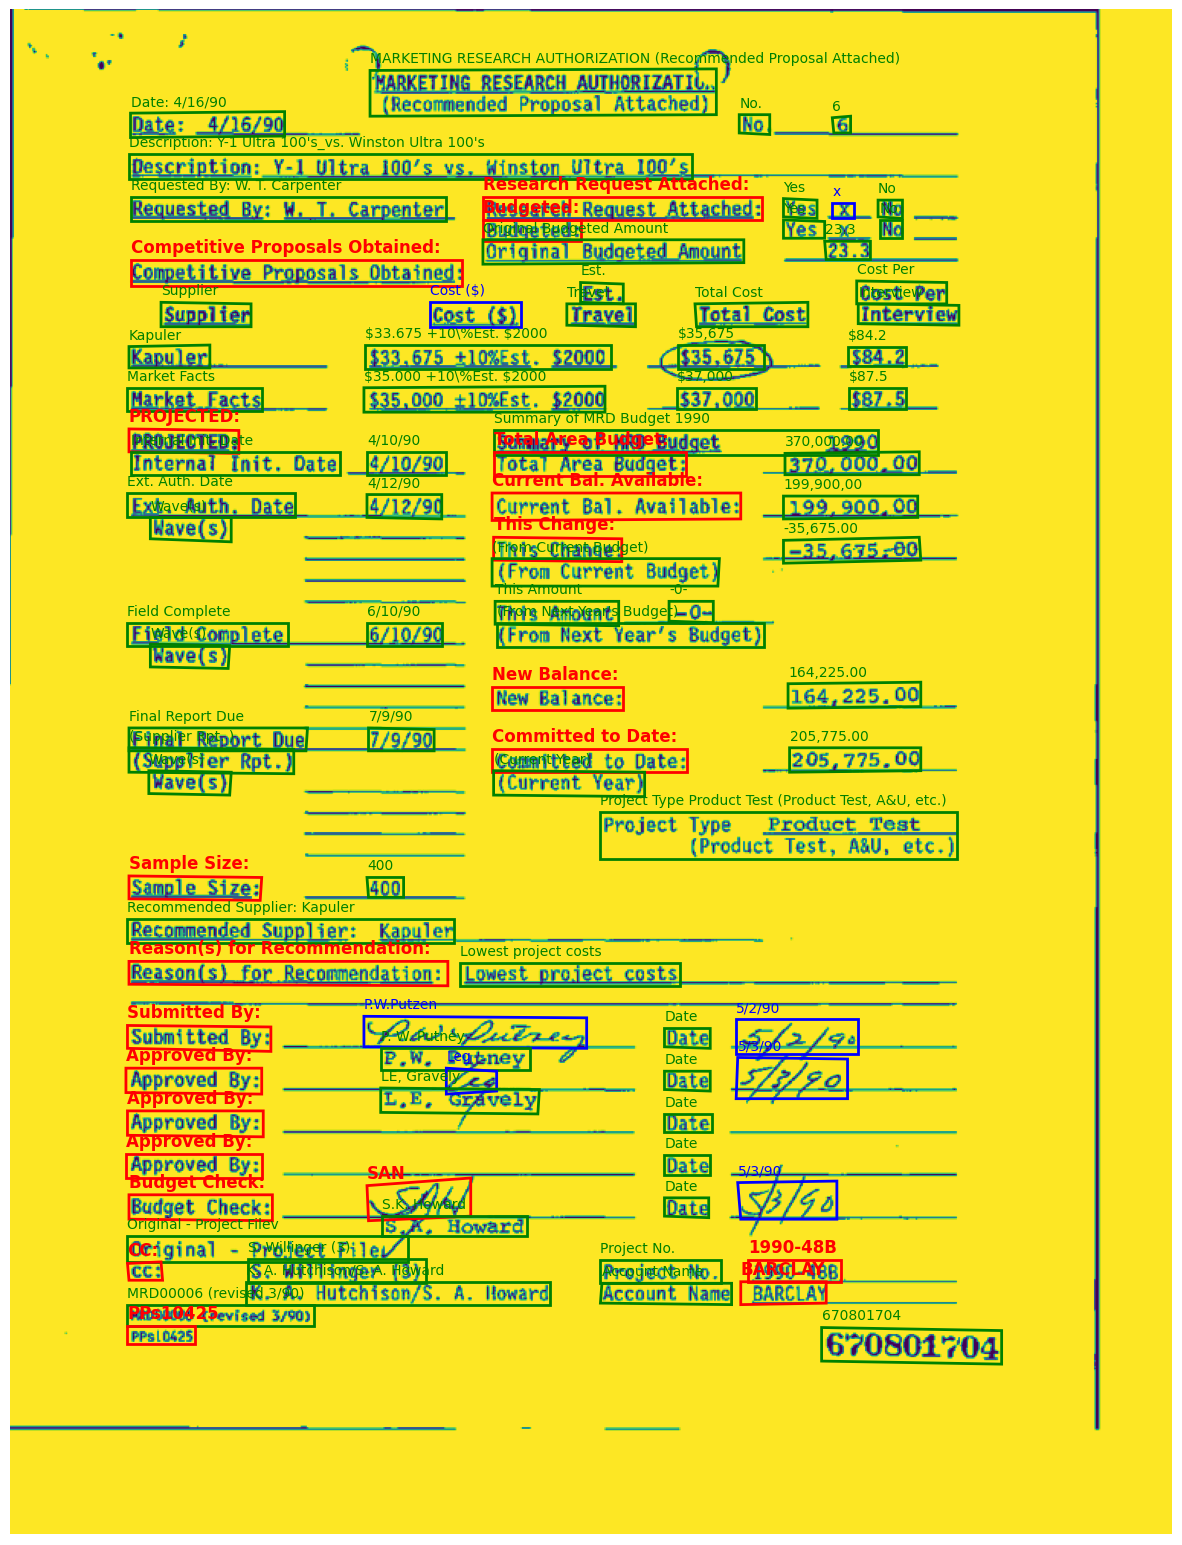

In [10]:
def plot_hierarchy_results(image_path, doc_structure, show_text=False):
    """
    Plot the hierarchical document structure over the image with bounding boxes.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image
    
    # Load the image
    image = Image.open(image_path)
    
    # Create a plot
    fig, ax = plt.subplots(1, figsize=(15, 20))
    ax.imshow(image)
    
    # Colors for different types of content
    colors = {
        'heading': 'red',
        'handwritten': 'blue',
        'normal': 'green'
    }
    
    def escape_text(text):
        """Helper function to escape special characters"""
        return text.replace('$', '\$').replace('%', '\%')
    
    # Plot each section
    for section in doc_structure:
        # Plot heading bounding box if available
        if 'polygon' in section:
            coords = [(point['x'], point['y']) for point in section['polygon']]
            poly_patch = patches.Polygon(coords, closed=True, 
                                      edgecolor=colors['heading'], 
                                      facecolor='none', 
                                      linewidth=2)
            ax.add_patch(poly_patch)
            if show_text:
                x, y = coords[0]
                ax.text(x, y - 5, escape_text(section['heading']), 
                       color=colors['heading'], 
                       fontsize=12, 
                       weight='bold')
        
        # Plot each line in the section
        for line in section['lines']:
            if 'polygon' in line:
                coords = [(point['x'], point['y']) for point in line['polygon']]
                color = colors['handwritten'] if line.get('is_handwritten') else colors['normal']
                poly_patch = patches.Polygon(coords, closed=True, 
                                          edgecolor=color, 
                                          facecolor='none', 
                                          linewidth=2)
                ax.add_patch(poly_patch)
                if show_text:
                    x, y = coords[0]
                    ax.text(x, y - 5, escape_text(line['text']), 
                           color=color, 
                           fontsize=10)
    
    # Set the axis limits to fit the image
    ax.set_xlim([0, image.width])
    ax.set_ylim([image.height, 0])
    ax.axis('off')
    
    plt.show()  # Removed tight_layout() as it was causing issues

# Test the visualization
# 1. Load your OCR JSON and process it
ocr_filename = '../datasets/FUNSD/training_data/annotations_azure_model__prebuilt_read/0001463282.json'
with open(ocr_filename, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

# 2. Parse into hierarchical structure
doc_structure = parse_ocr_into_hierarchy_with_columns(ocr_data)

# 3. Plot the results
image_path = '../datasets/FUNSD/training_data/images/0001463282.png'
plot_hierarchy_results(image_path, doc_structure, show_text=True)

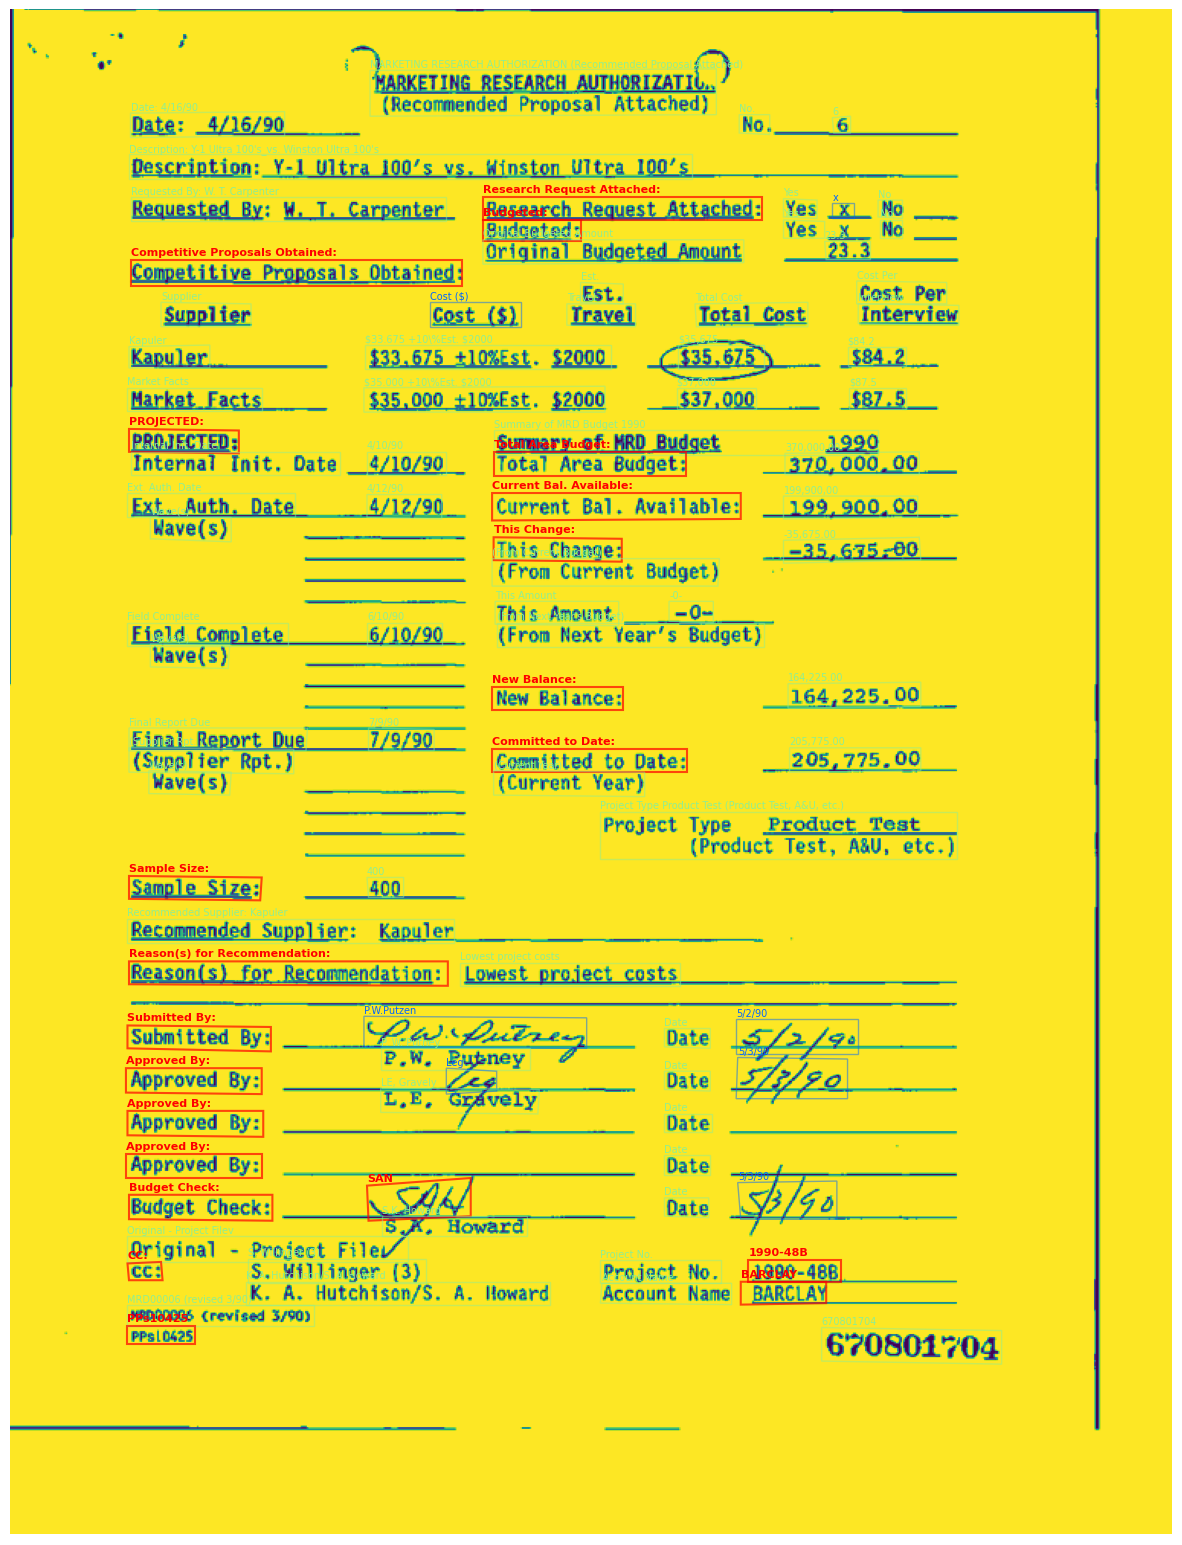

In [14]:
def plot_hierarchy_results(image_path, doc_structure, show_text=False):
    """
    Plot the hierarchical document structure over the image with bounding boxes.
    
    Args:
        image_path (str): Path to the image file
        doc_structure (list): The hierarchical structure returned by parse_ocr_into_hierarchy_with_columns
        show_text (bool): Whether to show text labels on the plot
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image
    
    # Load the image
    image = Image.open(image_path)
    
    # Create a plot
    fig, ax = plt.subplots(1, figsize=(15, 20))
    ax.imshow(image)
    
    # Colors for different types of content with better visibility
    colors = {
        'heading': '#FF0000',     # Pure red
        'handwritten': '#0066FF', # Bright blue
        'normal': '#90EE90'       # Light green
    }
    
    def escape_text(text):
        """Helper function to escape special characters"""
        return text.replace('$', '\$').replace('%', '\%')
    
    # Plot each section
    for section in doc_structure:
        # Plot heading bounding box if available
        if 'polygon' in section:
            coords = [(point['x'], point['y']) for point in section['polygon']]
            poly_patch = patches.Polygon(coords, closed=True, 
                                      edgecolor=colors['heading'], 
                                      facecolor='none', 
                                      alpha=0.7,        # Slight transparency
                                      linewidth=1.5)    # Thinner lines
            ax.add_patch(poly_patch)
            if show_text:
                x, y = coords[0]
                ax.text(x, y - 3, escape_text(section['heading']), 
                       color=colors['heading'], 
                       fontsize=8,      # Smaller text
                       weight='bold')
        
        # Plot each line in the section
        for line in section['lines']:
            if 'polygon' in line:
                coords = [(point['x'], point['y']) for point in line['polygon']]
                color = colors['handwritten'] if line.get('is_handwritten') else colors['normal']
                poly_patch = patches.Polygon(coords, closed=True, 
                                          edgecolor=color, 
                                          facecolor='none',
                                          alpha=0.5,    # More transparency for normal text
                                          linewidth=1)  # Thinner lines
                ax.add_patch(poly_patch)
                if show_text:
                    x, y = coords[0]
                    ax.text(x, y - 2, escape_text(line['text']), 
                           color=color, 
                           fontsize=7)  # Even smaller text for content
    
    # Set the axis limits to fit the image
    ax.set_xlim([0, image.width])
    ax.set_ylim([image.height, 0])
    ax.axis('off')
    
    plt.show()

# Test the visualization
# 1. Load your OCR JSON and process it
ocr_filename = '../datasets/FUNSD/training_data/annotations_azure_model__prebuilt_read/0001463282.json'
with open(ocr_filename, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

# 2. Parse into hierarchical structure
doc_structure = parse_ocr_into_hierarchy_with_columns(ocr_data)

# 3. Plot the results
image_path = '../datasets/FUNSD/training_data/images/0001463282.png'
plot_hierarchy_results(image_path, doc_structure, show_text=True)

def build_heading_hierarchy(sorted_lines, styles):
    """
    Modified to preserve polygon information for visualization
    """
    hierarchy = []
    current_section = None

    for line in sorted_lines:
        text = line["text"]
        if is_heading(text):
            new_heading = {
                "heading": text,
                "polygon": line["polygon"],  # Include polygon for heading
                "lines": []
            }
            hierarchy.append(new_heading)
            current_section = new_heading
        else:
            if not current_section:
                current_section = {
                    "heading": "Misc",
                    "lines": []
                }
                hierarchy.append(current_section)

            # Check if line is handwritten
            line_handwritten = is_line_handwritten(line["offset"], line["length"], styles)

            # append line with polygon information
            current_section["lines"].append({
                "text": text,
                "polygon": line["polygon"],  # Include polygon for line
                "is_handwritten": line_handwritten
            })

    return hierarchy

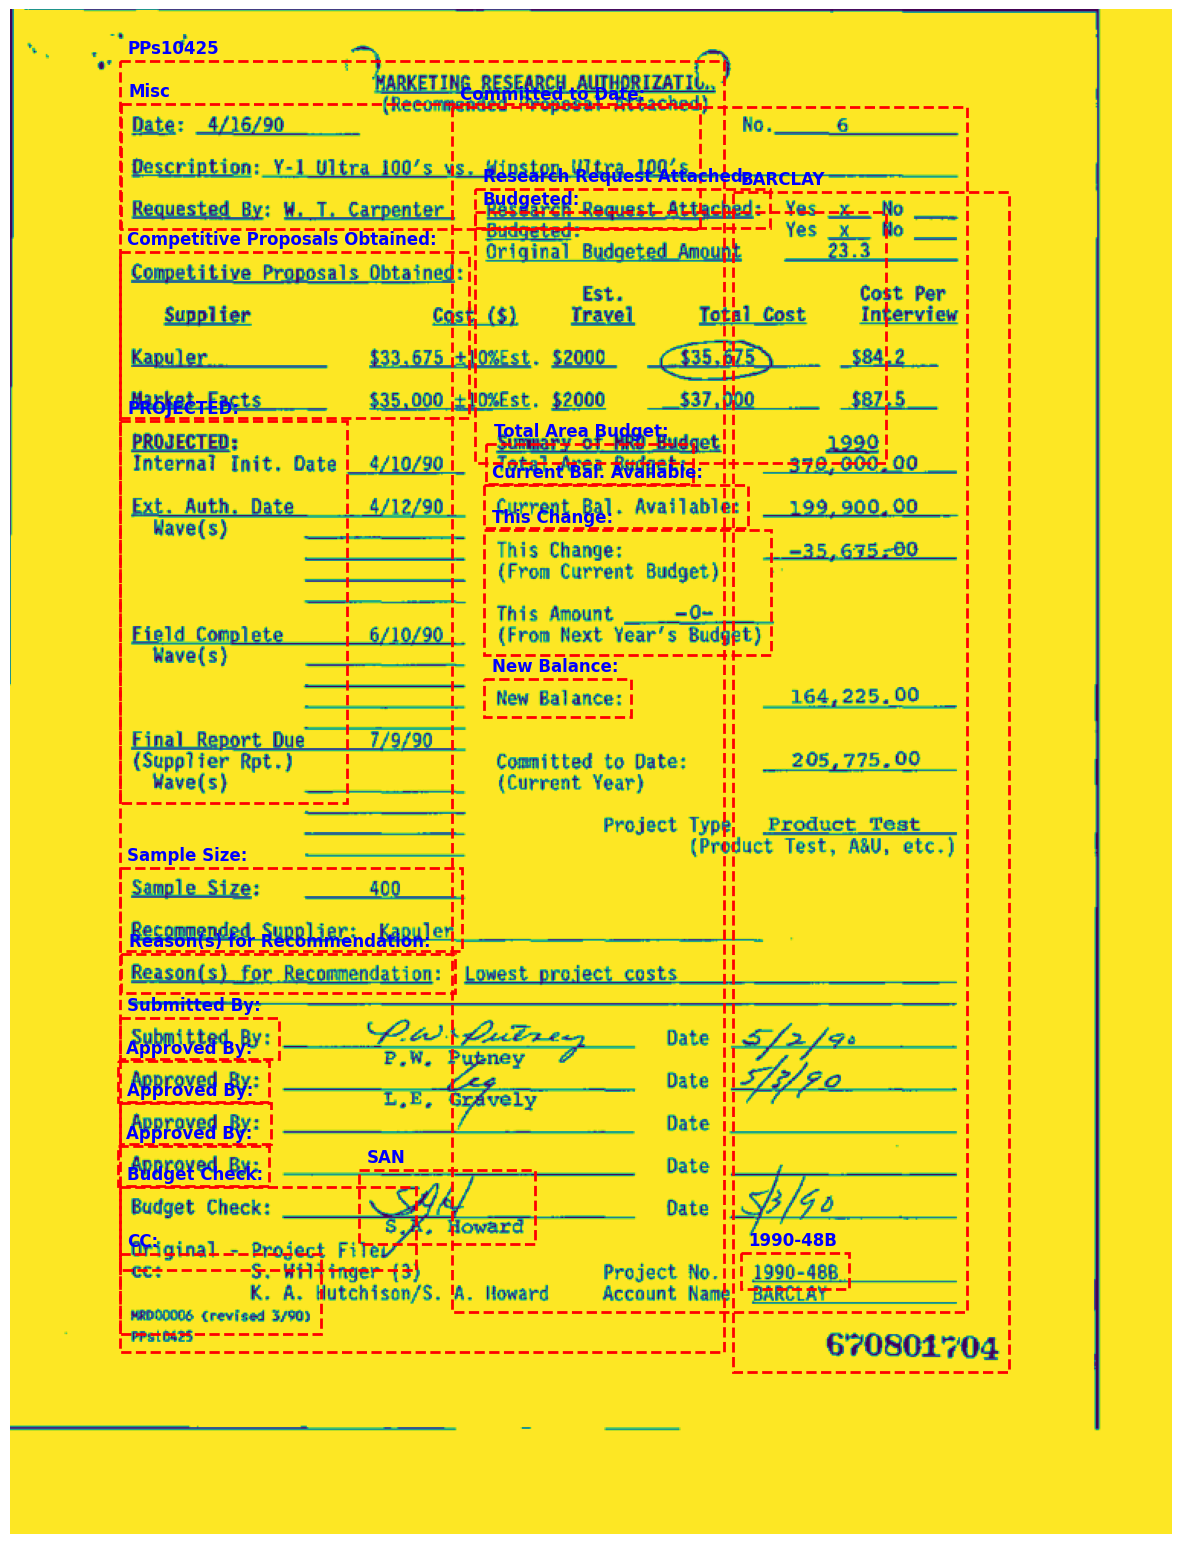

In [15]:
def plot_hierarchy_results(image_path, doc_structure, show_text=False):
    """
    Plot the hierarchical document structure over the image with section-level bounding boxes.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image
    
    # Load the image
    image = Image.open(image_path)
    
    # Create a plot
    fig, ax = plt.subplots(1, figsize=(15, 20))
    ax.imshow(image)
    
    # Colors for different types of content
    colors = {
        'section': 'red',          # Section bounding box
        'heading': 'blue',         # Heading text
        'handwritten': 'green',    # Handwritten content
        'normal': 'gray'          # Normal content
    }
    
    def escape_text(text):
        """Helper function to escape special characters"""
        return text.replace('$', '\$').replace('%', '\%')
    
    # Plot each section
    for section in doc_structure:
        # Collect all polygons in this section
        all_points = []
        
        # Add heading polygon if available
        if 'polygon' in section:
            points = [(point['x'], point['y']) for point in section['polygon']]
            all_points.extend(points)
        
        # Add all line polygons
        for line in section['lines']:
            if 'polygon' in line:
                points = [(point['x'], point['y']) for point in line['polygon']]
                all_points.extend(points)
        
        # If we have points, create a section bounding box
        if all_points:
            # Find the extremes to create section boundary
            min_x = min(p[0] for p in all_points)
            max_x = max(p[0] for p in all_points)
            min_y = min(p[1] for p in all_points)
            max_y = max(p[1] for p in all_points)
            
            # Add some padding
            padding = 5
            section_coords = [
                (min_x - padding, min_y - padding),
                (max_x + padding, min_y - padding),
                (max_x + padding, max_y + padding),
                (min_x - padding, max_y + padding)
            ]
            
            # Draw section bounding box
            section_patch = patches.Polygon(section_coords, closed=True,
                                         edgecolor=colors['section'],
                                         facecolor='none',
                                         linewidth=2,
                                         linestyle='--')  # Dashed line for sections
            ax.add_patch(section_patch)
            
            # Add section heading text
            if show_text:
                ax.text(min_x, min_y - 10, escape_text(section['heading']),
                       color=colors['heading'],
                       fontsize=12,
                       weight='bold')
    
    # Set the axis limits to fit the image
    ax.set_xlim([0, image.width])
    ax.set_ylim([image.height, 0])
    ax.axis('off')
    
    plt.show()

# Test the visualization
# 1. Load your OCR JSON and process it
ocr_filename = '../datasets/FUNSD/training_data/annotations_azure_model__prebuilt_read/0001463282.json'
with open(ocr_filename, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

# 2. Parse into hierarchical structure
doc_structure = parse_ocr_into_hierarchy_with_columns(ocr_data)

# 3. Plot the results
image_path = '../datasets/FUNSD/training_data/images/0001463282.png'
plot_hierarchy_results(image_path, doc_structure, show_text=True)

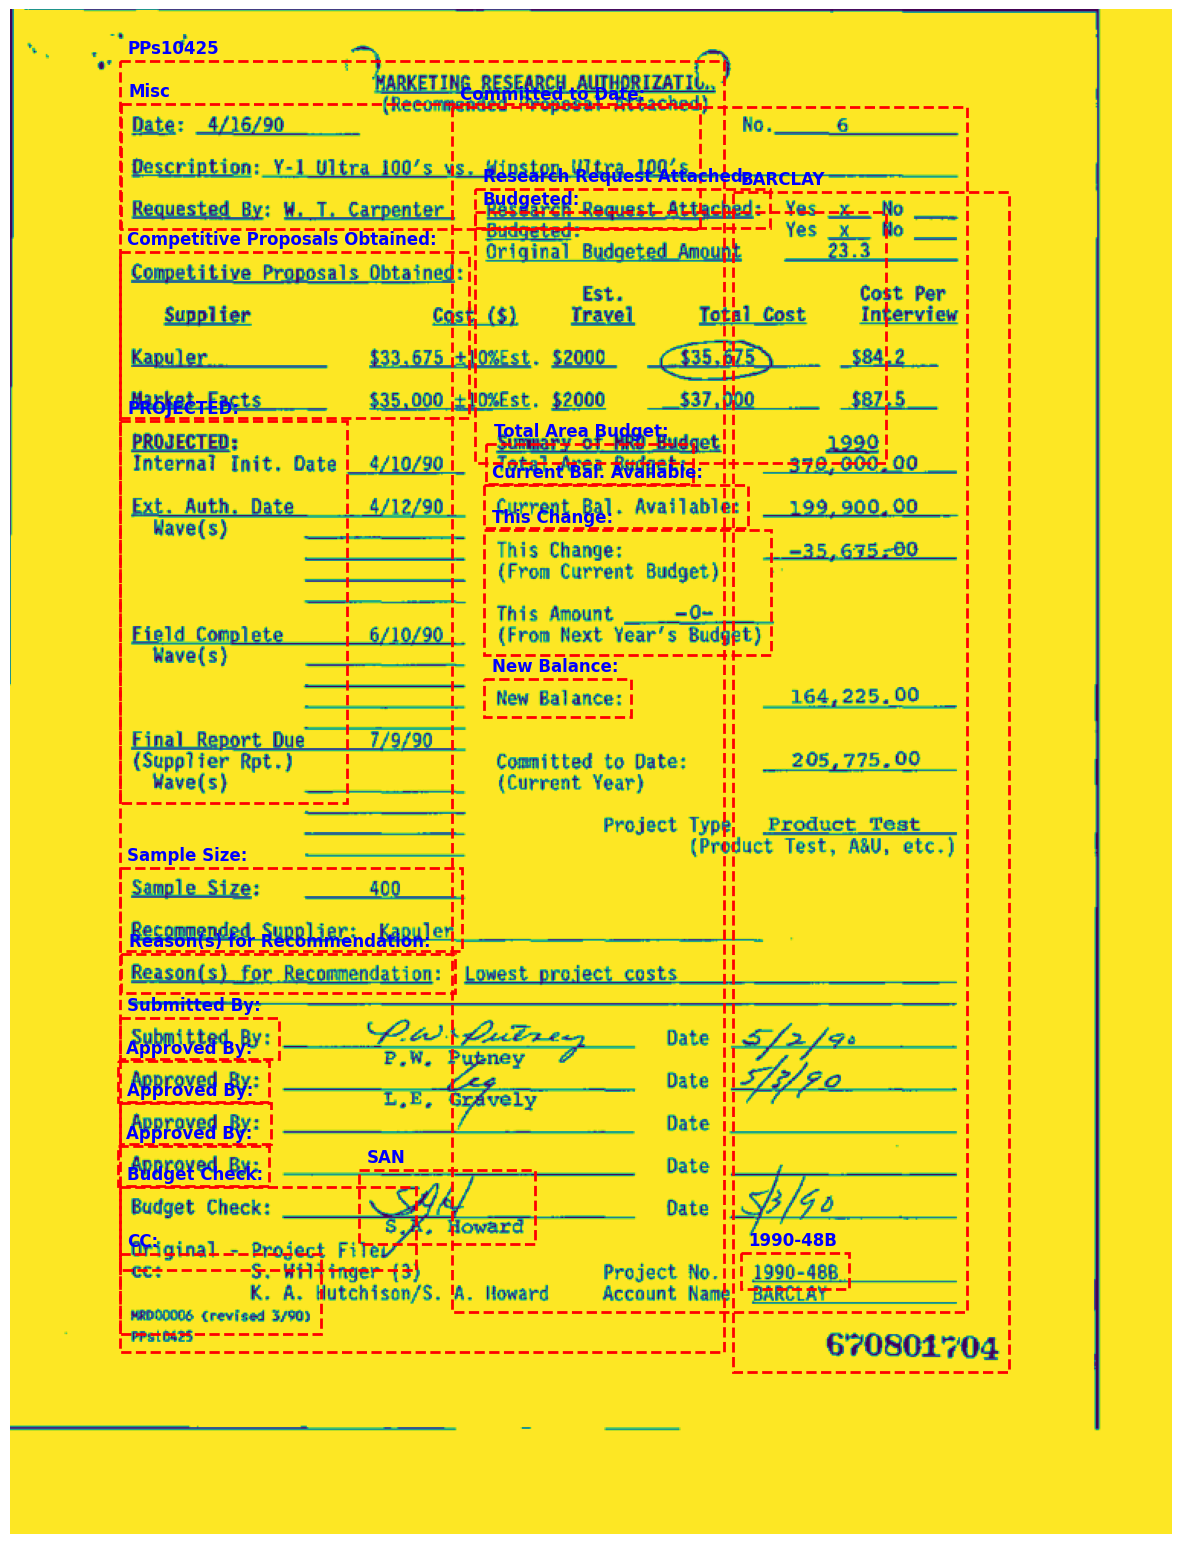

In [16]:
def plot_hierarchy_results(image_path, doc_structure, show_text=False):
    """
    Plot the hierarchical document structure over the image with section-level bounding boxes.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image
    
    # Load the image
    image = Image.open(image_path)
    
    # Create a plot
    fig, ax = plt.subplots(1, figsize=(15, 20))
    ax.imshow(image)
    
    # Colors for different types of content
    colors = {
        'section': 'red',          # Section bounding box
        'heading': 'blue',         # Heading text
        'handwritten': 'green',    # Handwritten content
        'normal': 'gray'          # Normal content
    }
    
    def escape_text(text):
        """Helper function to escape special characters"""
        return text.replace('$', '\$').replace('%', '\%')
    
    # Plot each section
    for section in doc_structure:
        # Collect all points from the section (heading and lines)
        all_points = []
        
        # Add heading polygon if available
        if 'polygon' in section:
            points = [(point['x'], point['y']) for point in section['polygon']]
            all_points.extend(points)
        
        # Add all line polygons
        for line in section['lines']:
            if 'polygon' in line:
                points = [(point['x'], point['y']) for point in line['polygon']]
                all_points.extend(points)
        
        # If we have points, create a section bounding box
        if all_points:
            # Find the extremes to create section boundary
            min_x = min(p[0] for p in all_points)
            max_x = max(p[0] for p in all_points)
            min_y = min(p[1] for p in all_points)
            max_y = max(p[1] for p in all_points)
            
            # Add some padding
            padding = 5
            section_coords = [
                (min_x - padding, min_y - padding),
                (max_x + padding, min_y - padding),
                (max_x + padding, max_y + padding),
                (min_x - padding, max_y + padding)
            ]
            
            # Draw section bounding box
            section_patch = patches.Polygon(section_coords, closed=True,
                                         edgecolor=colors['section'],
                                         facecolor='none',
                                         linewidth=2,
                                         linestyle='--')  # Dashed line for sections
            ax.add_patch(section_patch)
            
            # Add section heading text
            if show_text:
                ax.text(min_x, min_y - 10, escape_text(section['heading']),
                       color=colors['heading'],
                       fontsize=12,
                       weight='bold')
    
    # Set the axis limits to fit the image
    ax.set_xlim([0, image.width])
    ax.set_ylim([image.height, 0])
    ax.axis('off')
    
    plt.show()

# Test the visualization
# 1. Load your OCR JSON and process it
ocr_filename = '../datasets/FUNSD/training_data/annotations_azure_model__prebuilt_read/0001463282.json'
with open(ocr_filename, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

# 2. Parse into hierarchical structure
doc_structure = parse_ocr_into_hierarchy_with_columns(ocr_data)

# 3. Plot the results
image_path = '../datasets/FUNSD/training_data/images/0001463282.png'
plot_hierarchy_results(image_path, doc_structure, show_text=True)

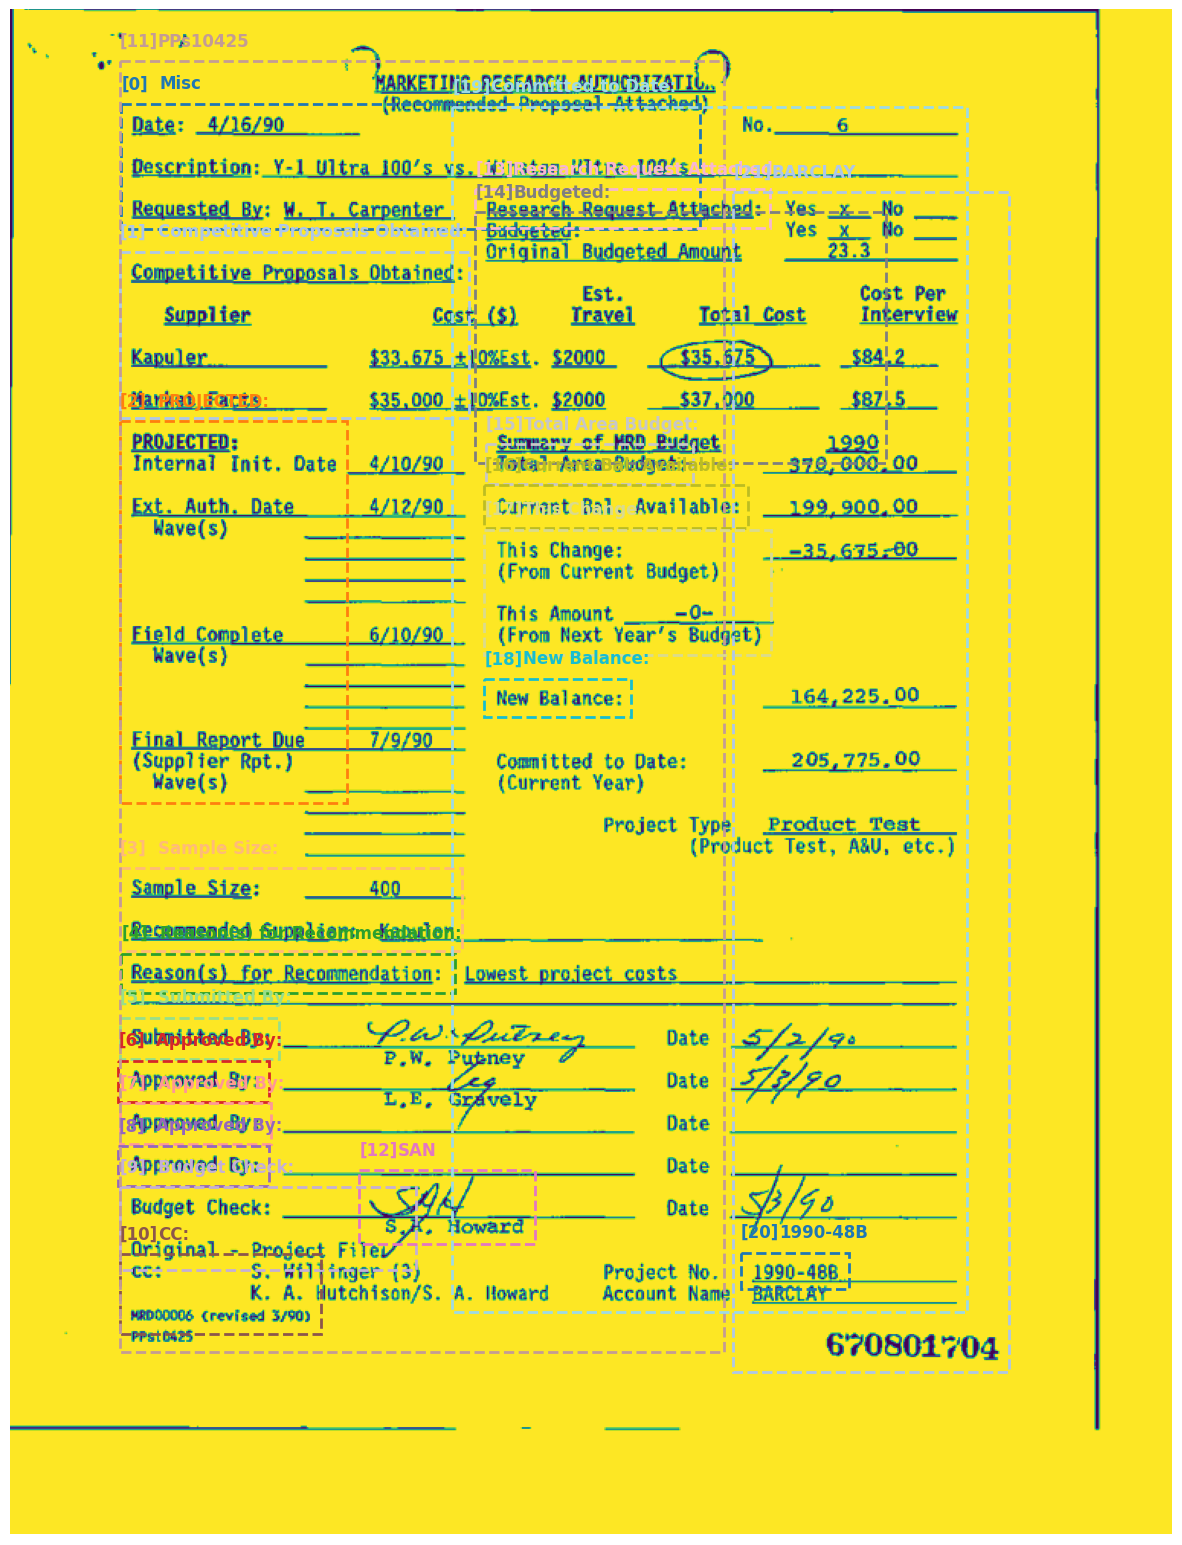

In [18]:
import numpy as np
def plot_hierarchy_results(image_path, doc_structure, show_text=False):
    """
    Plot the hierarchical document structure over the image with section-level bounding boxes.
    Each section gets a unique ID and color.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image
    import matplotlib.colors as mcolors
    
    # Load the image
    image = Image.open(image_path)
    
    # Create a plot
    fig, ax = plt.subplots(1, figsize=(15, 20))
    ax.imshow(image)
    
    # Create a color palette for sections
    # Using distinct colors from matplotlib's tab20 colormap
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    
    def escape_text(text):
        """Helper function to escape special characters"""
        return text.replace('$', '\$').replace('%', '\%')
    
    # Plot each section
    for idx, section in enumerate(doc_structure):
        # Get color for this section
        color = colors[idx % 20]  # Cycle through colors if more than 20 sections
        
        # Collect all points from the section (heading and lines)
        all_points = []
        
        # Add heading polygon if available
        if 'polygon' in section:
            points = [(point['x'], point['y']) for point in section['polygon']]
            all_points.extend(points)
        
        # Add all line polygons
        for line in section['lines']:
            if 'polygon' in line:
                points = [(point['x'], point['y']) for point in line['polygon']]
                all_points.extend(points)
        
        # If we have points, create a section bounding box
        if all_points:
            # Find the extremes to create section boundary
            min_x = min(p[0] for p in all_points)
            max_x = max(p[0] for p in all_points)
            min_y = min(p[1] for p in all_points)
            max_y = max(p[1] for p in all_points)
            
            # Add some padding
            padding = 5
            section_coords = [
                (min_x - padding, min_y - padding),
                (max_x + padding, min_y - padding),
                (max_x + padding, max_y + padding),
                (min_x - padding, max_y + padding)
            ]
            
            # Draw section bounding box
            section_patch = patches.Polygon(section_coords, closed=True,
                                         edgecolor=color,
                                         facecolor='none',
                                         linewidth=2,
                                         linestyle='--')  # Dashed line for sections
            ax.add_patch(section_patch)
            
            # Add section ID and heading text
            if show_text:
                # Add section ID
                ax.text(min_x - padding, min_y - 15, f"[{idx}]",
                       color=color,
                       fontsize=12,
                       weight='bold')
                
                # Add heading text
                ax.text(min_x + 20, min_y - 15, escape_text(section['heading']),
                       color=color,
                       fontsize=12,
                       weight='bold')
    
    # Set the axis limits to fit the image
    ax.set_xlim([0, image.width])
    ax.set_ylim([image.height, 0])
    ax.axis('off')
    
    plt.show()

# Test the visualization
# 1. Load your OCR JSON and process it
ocr_filename = '../datasets/FUNSD/training_data/annotations_azure_model__prebuilt_read/0001463282.json'
with open(ocr_filename, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

# 2. Parse into hierarchical structure
doc_structure = parse_ocr_into_hierarchy_with_columns(ocr_data)

# 3. Plot the results
image_path = '../datasets/FUNSD/training_data/images/0001463282.png'
plot_hierarchy_results(image_path, doc_structure, show_text=True)

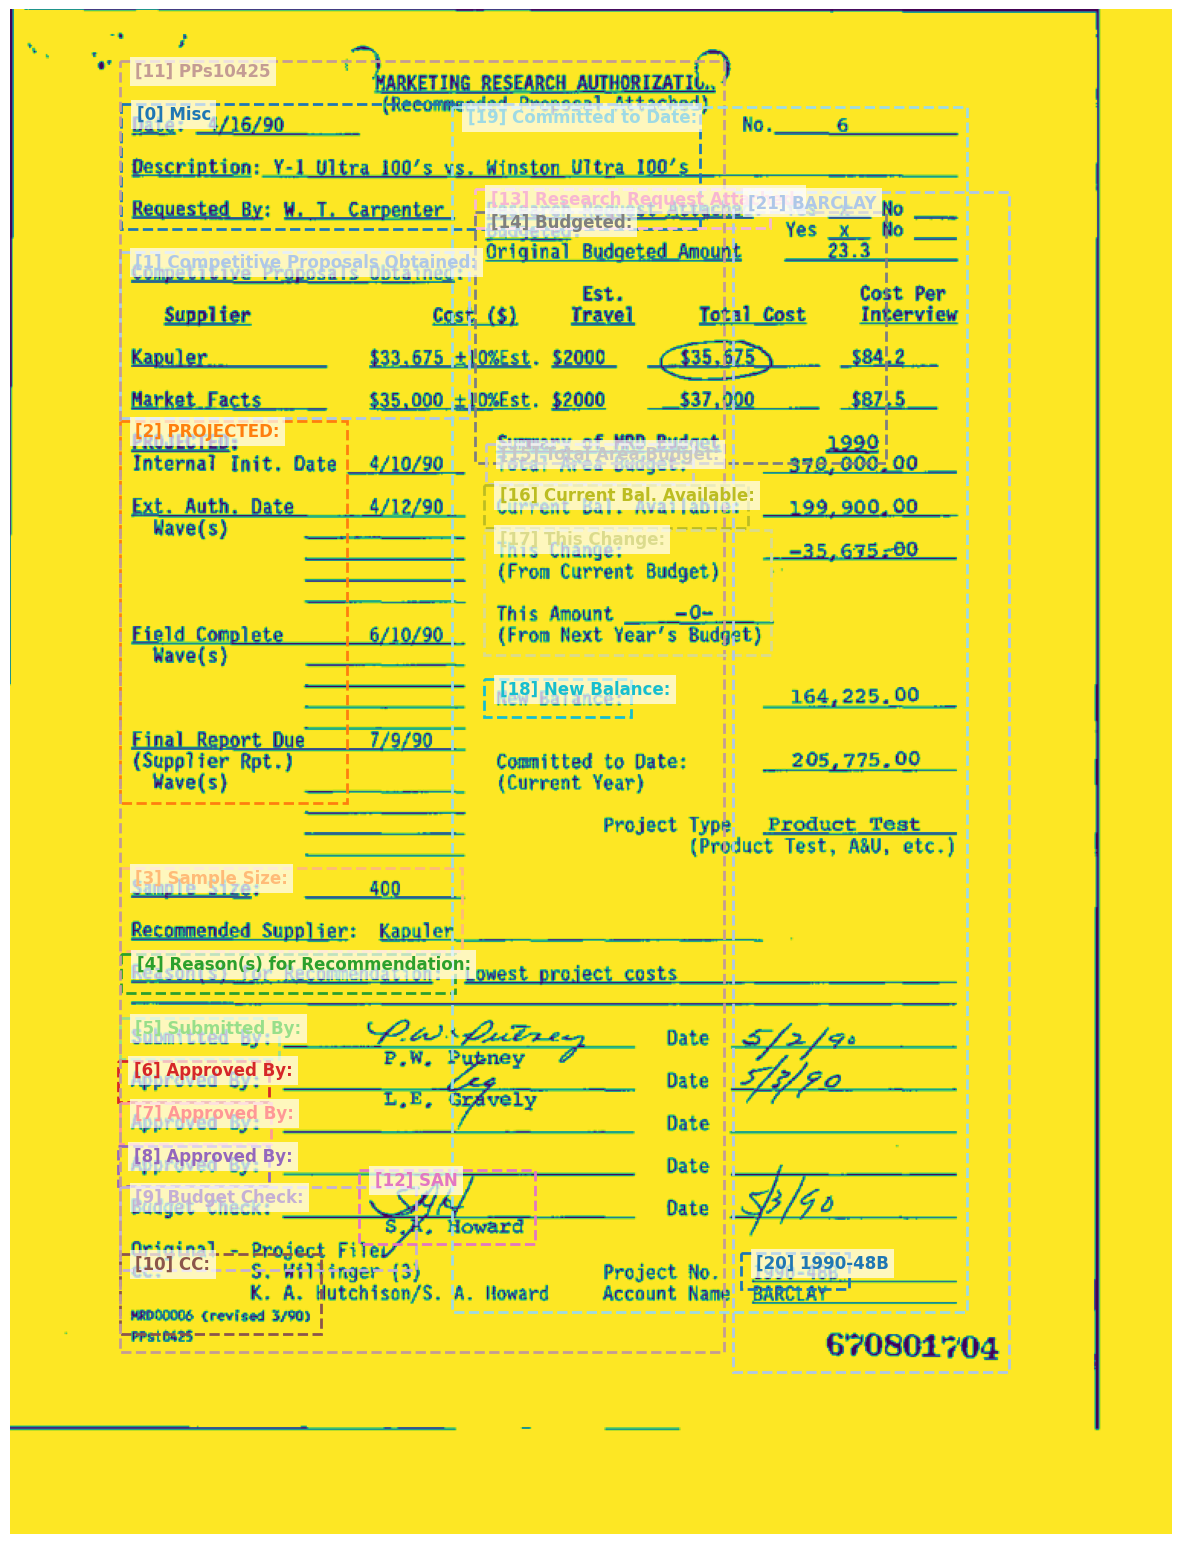

In [20]:
def plot_hierarchy_results(image_path, doc_structure, show_text=False):
    """
    Plot the hierarchical document structure over the image with section-level bounding boxes.
    Each section gets a unique ID and color, with heading text inside the box.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image
    import matplotlib.colors as mcolors
    
    # Load the image
    image = Image.open(image_path)
    
    # Create a plot
    fig, ax = plt.subplots(1, figsize=(15, 20))
    ax.imshow(image)
    
    # Create a color palette for sections
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    
    def escape_text(text):
        """Helper function to escape special characters"""
        return text.replace('$', '\$').replace('%', '\%')
    
    # Plot each section
    for idx, section in enumerate(doc_structure):
        # Get color for this section
        color = colors[idx % 20]  # Cycle through colors if more than 20 sections
        
        # Collect all points from the section (heading and lines)
        all_points = []
        
        # Add heading polygon if available
        if 'polygon' in section:
            points = [(point['x'], point['y']) for point in section['polygon']]
            all_points.extend(points)
        
        # Add all line polygons
        for line in section['lines']:
            if 'polygon' in line:
                points = [(point['x'], point['y']) for point in line['polygon']]
                all_points.extend(points)
        
        # If we have points, create a section bounding box
        if all_points:
            # Find the extremes to create section boundary
            min_x = min(p[0] for p in all_points)
            max_x = max(p[0] for p in all_points)
            min_y = min(p[1] for p in all_points)
            max_y = max(p[1] for p in all_points)
            
            # Add some padding
            padding = 5
            section_coords = [
                (min_x - padding, min_y - padding),
                (max_x + padding, min_y - padding),
                (max_x + padding, max_y + padding),
                (min_x - padding, max_y + padding)
            ]
            
            # Draw section bounding box
            section_patch = patches.Polygon(section_coords, closed=True,
                                         edgecolor=color,
                                         facecolor='none',
                                         linewidth=2,
                                         linestyle='--')  # Dashed line for sections
            ax.add_patch(section_patch)
            
            # Add section ID and heading text
            if show_text:
                # Add section ID and heading text inside the box at the top
                text = f"[{idx}] {escape_text(section['heading'])}"
                ax.text(min_x + padding, min_y + padding, text,
                       color=color,
                       fontsize=12,
                       weight='bold',
                       bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))  # Add white background for better readability
    
    # Set the axis limits to fit the image
    ax.set_xlim([0, image.width])
    ax.set_ylim([image.height, 0])
    ax.axis('off')
    
    plt.show()

# Test the visualization
# 1. Load your OCR JSON and process it
ocr_filename = '../datasets/FUNSD/training_data/annotations_azure_model__prebuilt_read/0001463282.json'
with open(ocr_filename, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

# 2. Parse into hierarchical structure
doc_structure = parse_ocr_into_hierarchy_with_columns(ocr_data)

# 3. Plot the results
image_path = '../datasets/FUNSD/training_data/images/0001463282.png'
plot_hierarchy_results(image_path, doc_structure, show_text=True)

Showing all sections:


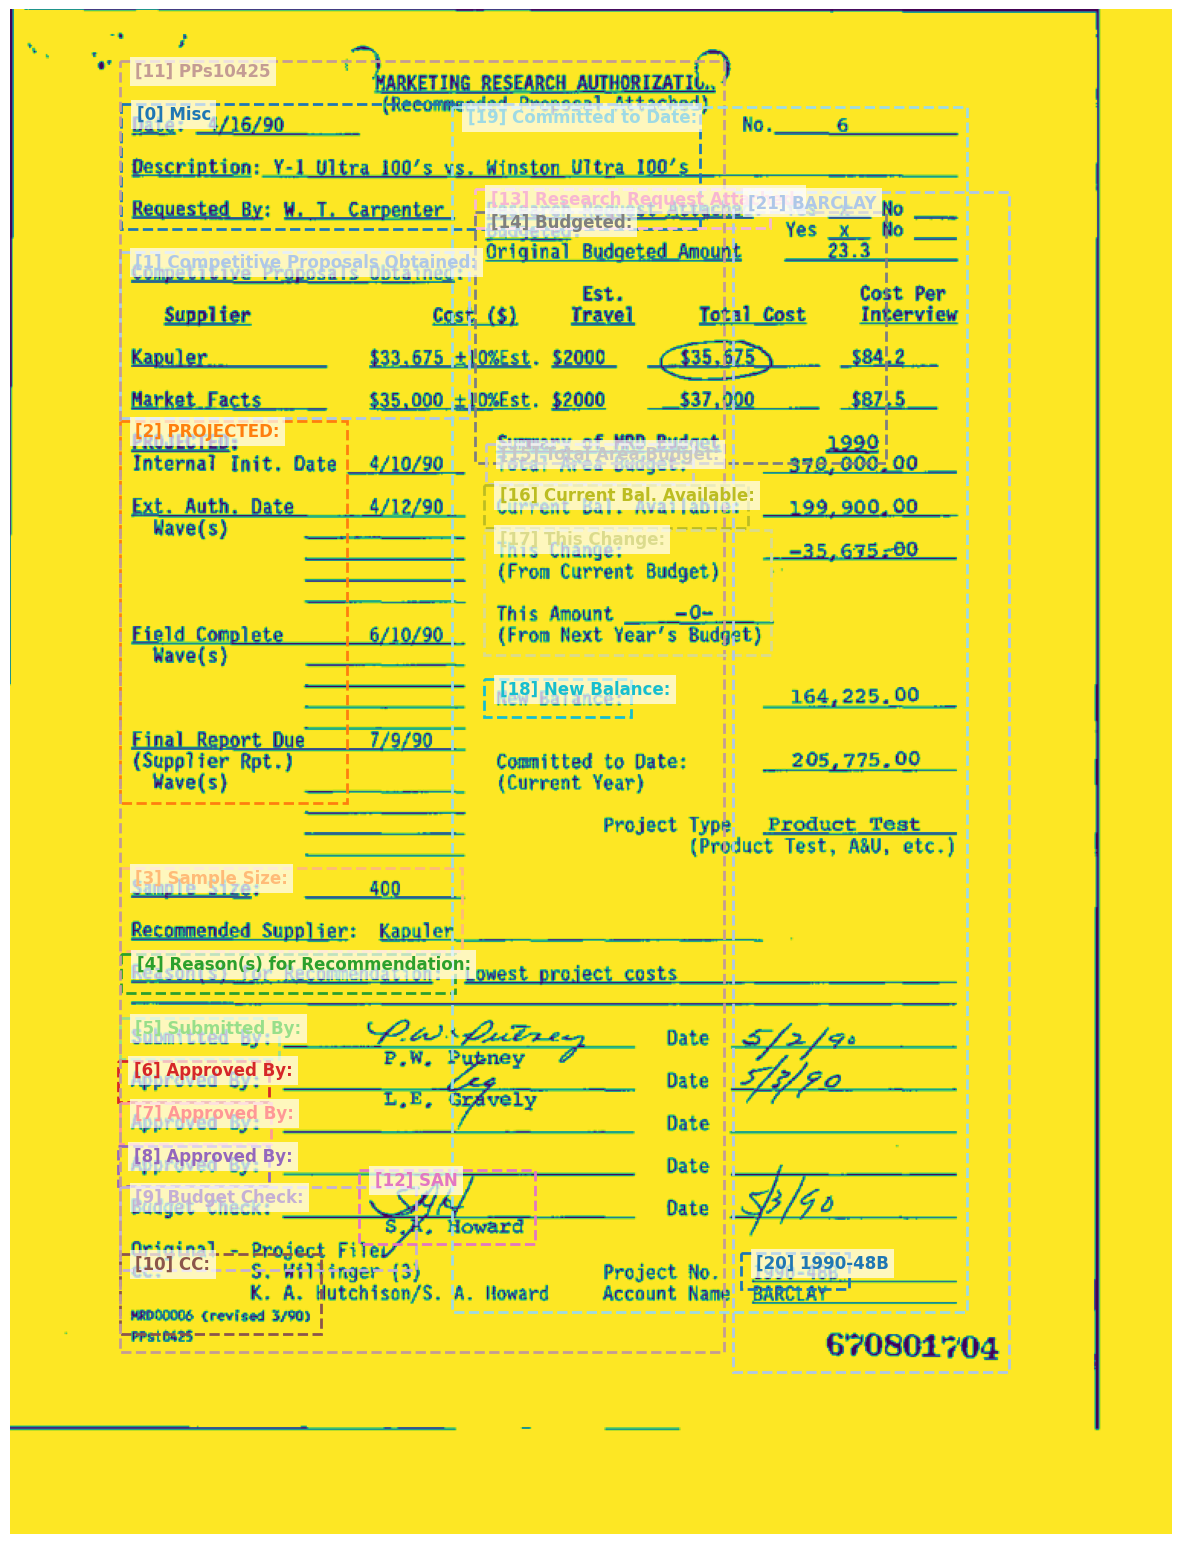


Showing only section 0:


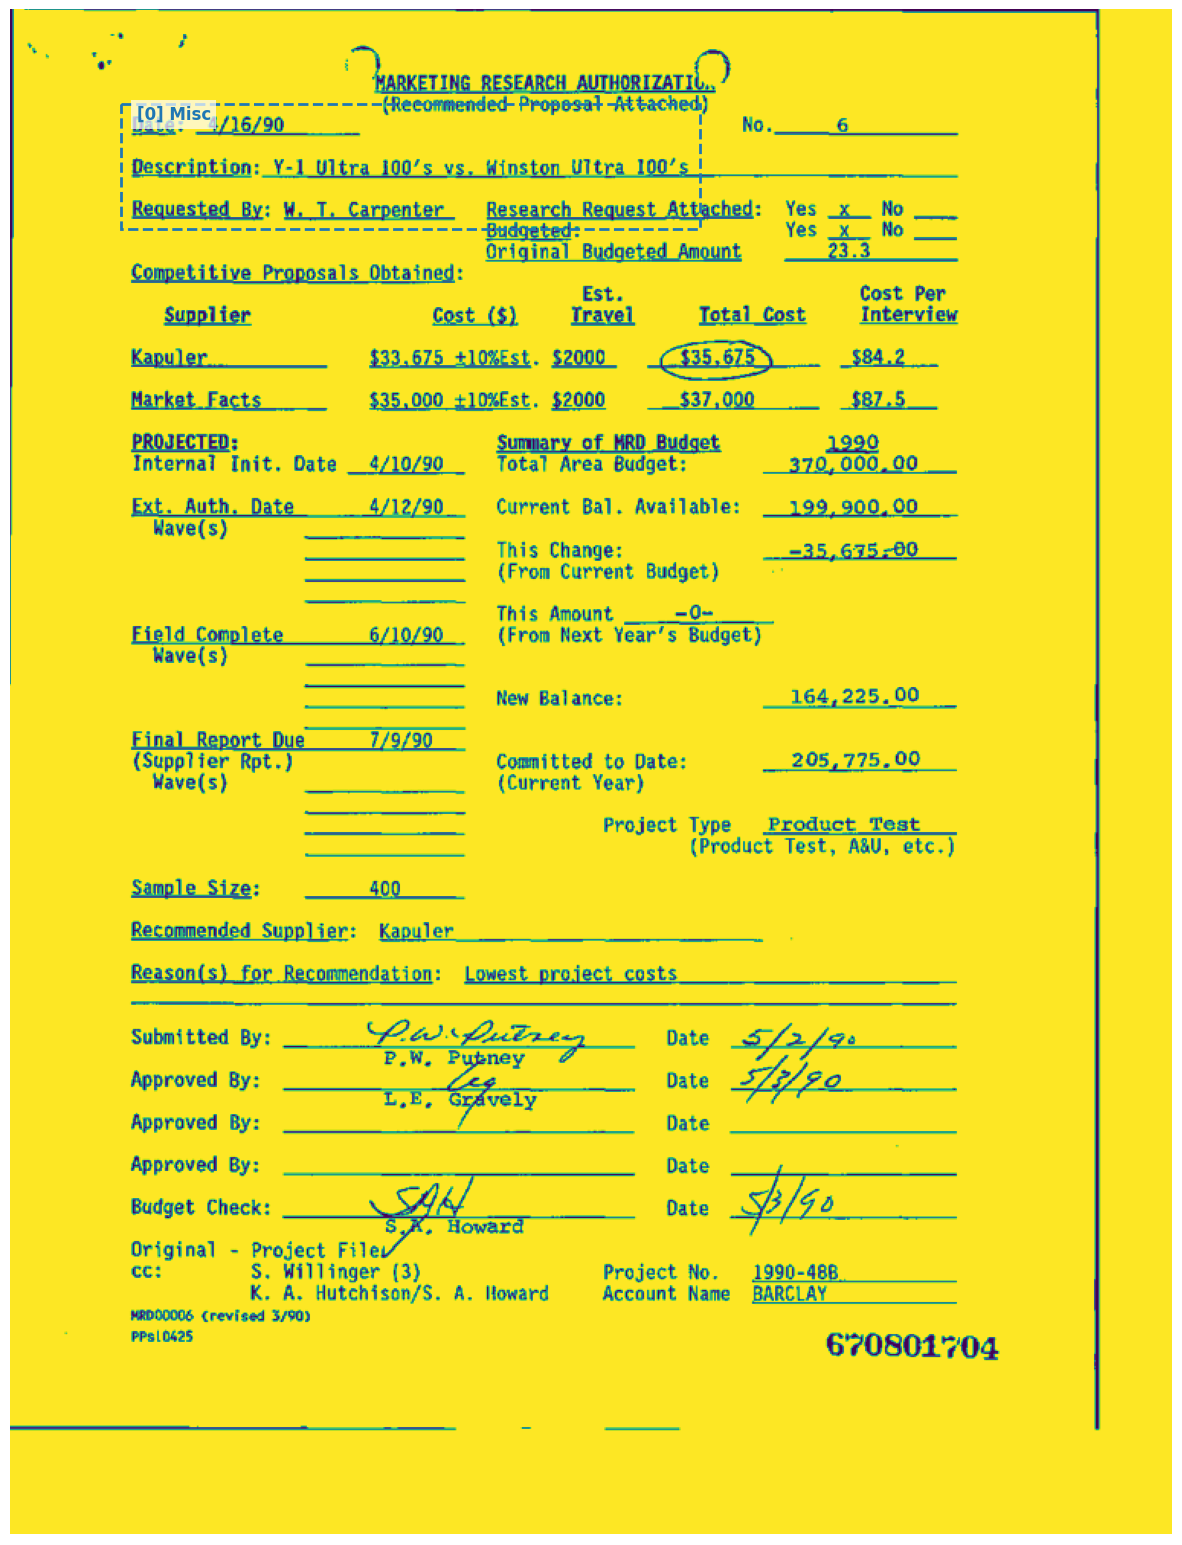


Showing sections 0, 2, and 4:


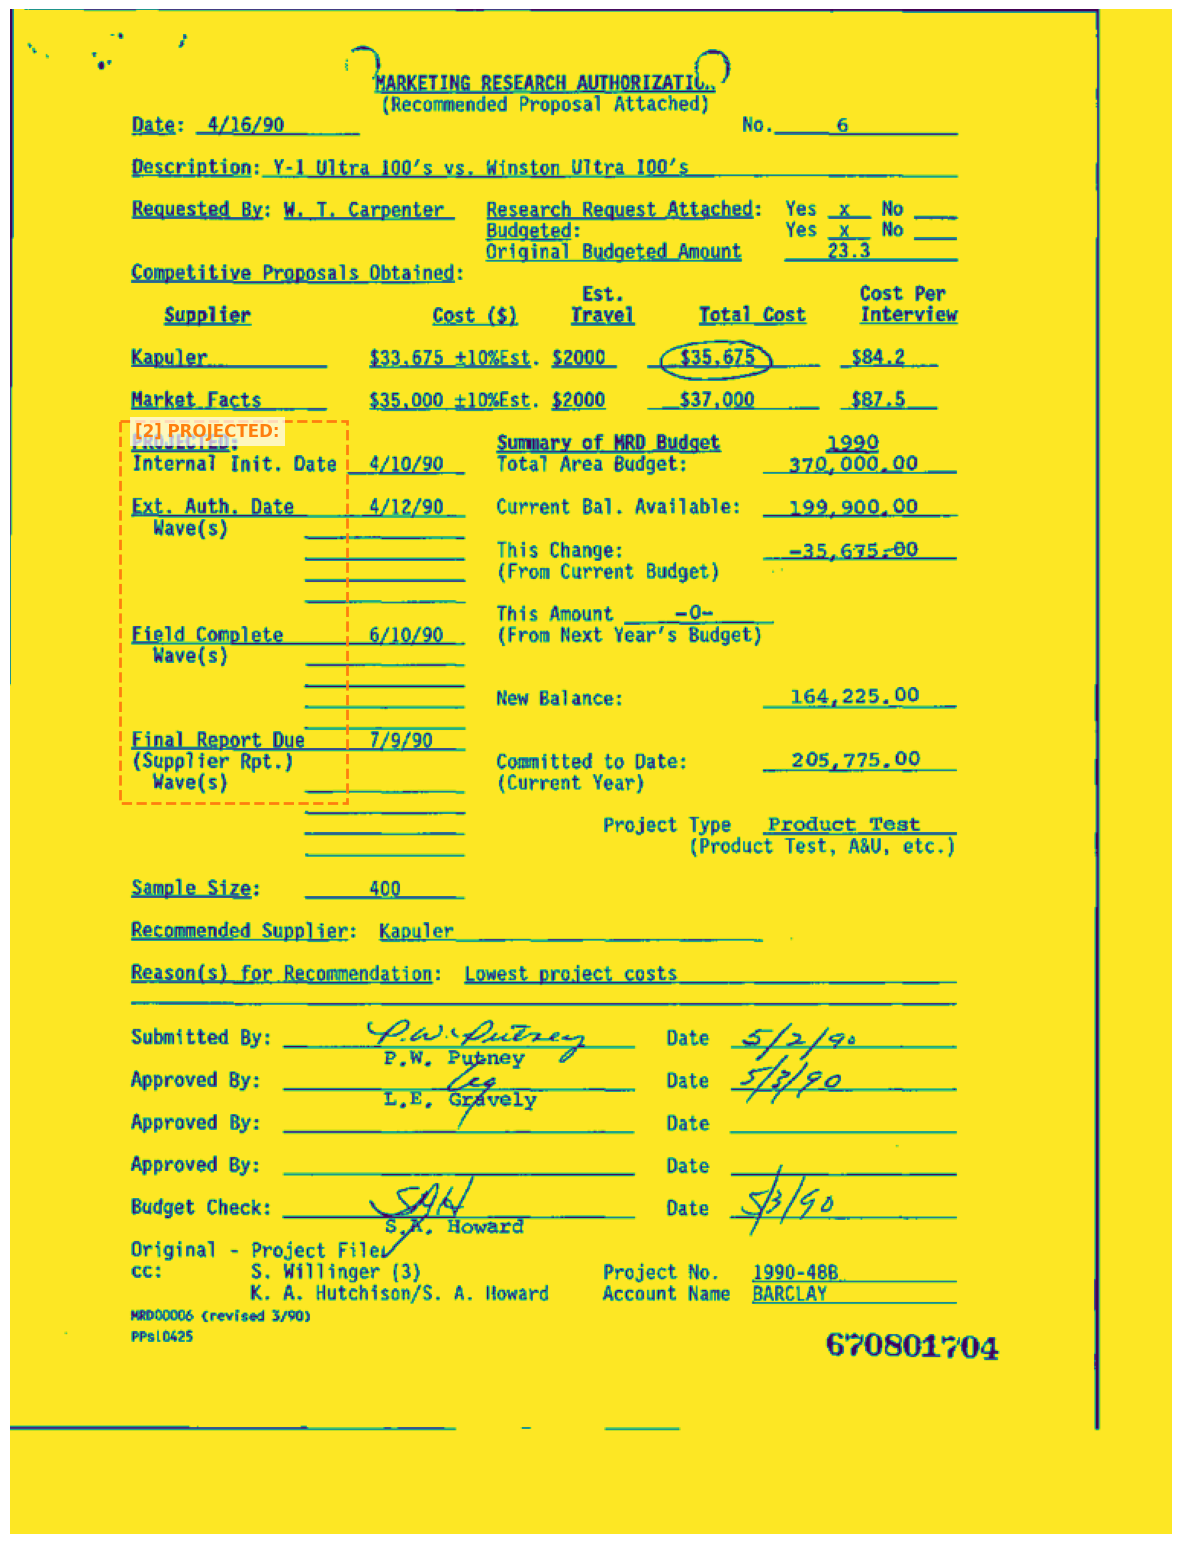

In [22]:
def plot_hierarchy_results(image_path, doc_structure, show_text=False, section_ids=None):
    """
    Plot the hierarchical document structure over the image with section-level bounding boxes.
    
    Args:
        image_path (str): Path to the image file
        doc_structure (list): The hierarchical structure
        show_text (bool): Whether to show text labels
        section_ids (int or list): Specific section ID(s) to display. If None, shows all sections
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image
    import matplotlib.colors as mcolors
    
    # Convert single ID to list for consistent processing
    if isinstance(section_ids, int):
        section_ids = [section_ids]
    
    # Load the image
    image = Image.open(image_path)
    
    # Create a plot
    fig, ax = plt.subplots(1, figsize=(15, 20))
    ax.imshow(image)
    
    # Create a color palette for sections
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    
    def escape_text(text):
        """Helper function to escape special characters"""
        return text.replace('$', '\$').replace('%', '\%')
    
    # Plot each section
    for idx, section in enumerate(doc_structure):
        # Skip if we're filtering and this section isn't in the list
        if section_ids is not None and idx not in section_ids:
            continue
            
        # Get color for this section
        color = colors[idx % 20]  # Cycle through colors if more than 20 sections
        
        # Collect all points from the section (heading and lines)
        all_points = []
        
        # Add heading polygon if available
        if 'polygon' in section:
            points = [(point['x'], point['y']) for point in section['polygon']]
            all_points.extend(points)
        
        # Add all line polygons
        for line in section['lines']:
            if 'polygon' in line:
                points = [(point['x'], point['y']) for point in line['polygon']]
                all_points.extend(points)
        
        # If we have points, create a section bounding box
        if all_points:
            # Find the extremes to create section boundary
            min_x = min(p[0] for p in all_points)
            max_x = max(p[0] for p in all_points)
            min_y = min(p[1] for p in all_points)
            max_y = max(p[1] for p in all_points)
            
            # Add some padding
            padding = 5
            section_coords = [
                (min_x - padding, min_y - padding),
                (max_x + padding, min_y - padding),
                (max_x + padding, max_y + padding),
                (min_x - padding, max_y + padding)
            ]
            
            # Draw section bounding box
            section_patch = patches.Polygon(section_coords, closed=True,
                                         edgecolor=color,
                                         facecolor='none',
                                         linewidth=2,
                                         linestyle='--')  # Dashed line for sections
            ax.add_patch(section_patch)
            
            # Add section ID and heading text
            if show_text:
                # Add section ID and heading text inside the box at the top
                text = f"[{idx}] {escape_text(section['heading'])}"
                ax.text(min_x + padding, min_y + padding, text,
                       color=color,
                       fontsize=12,
                       weight='bold',
                       bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Set the axis limits to fit the image
    ax.set_xlim([0, image.width])
    ax.set_ylim([image.height, 0])
    ax.axis('off')
    
    plt.show()

# Test the visualization with different filters
# 1. Load your OCR JSON and process it
ocr_filename = '../datasets/FUNSD/training_data/annotations_azure_model__prebuilt_read/0001463282.json'
with open(ocr_filename, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

# 2. Parse into hierarchical structure
doc_structure = parse_ocr_into_hierarchy_with_columns(ocr_data)

# 3. Plot the results with different filters
image_path = '../datasets/FUNSD/training_data/images/0001463282.png'

# Show all sections
print("Showing all sections:")
plot_hierarchy_results(image_path, doc_structure, show_text=True)

# Show single section (e.g., section 0)
print("\nShowing only section 0:")
plot_hierarchy_results(image_path, doc_structure, show_text=True, section_ids=0)

# Show multiple sections (e.g., sections 0, 2, and 4)
print("\nShowing sections 0, 2, and 4:")
plot_hierarchy_results(image_path, doc_structure, show_text=True, section_ids=[2])


Showing hierarchy level 1:


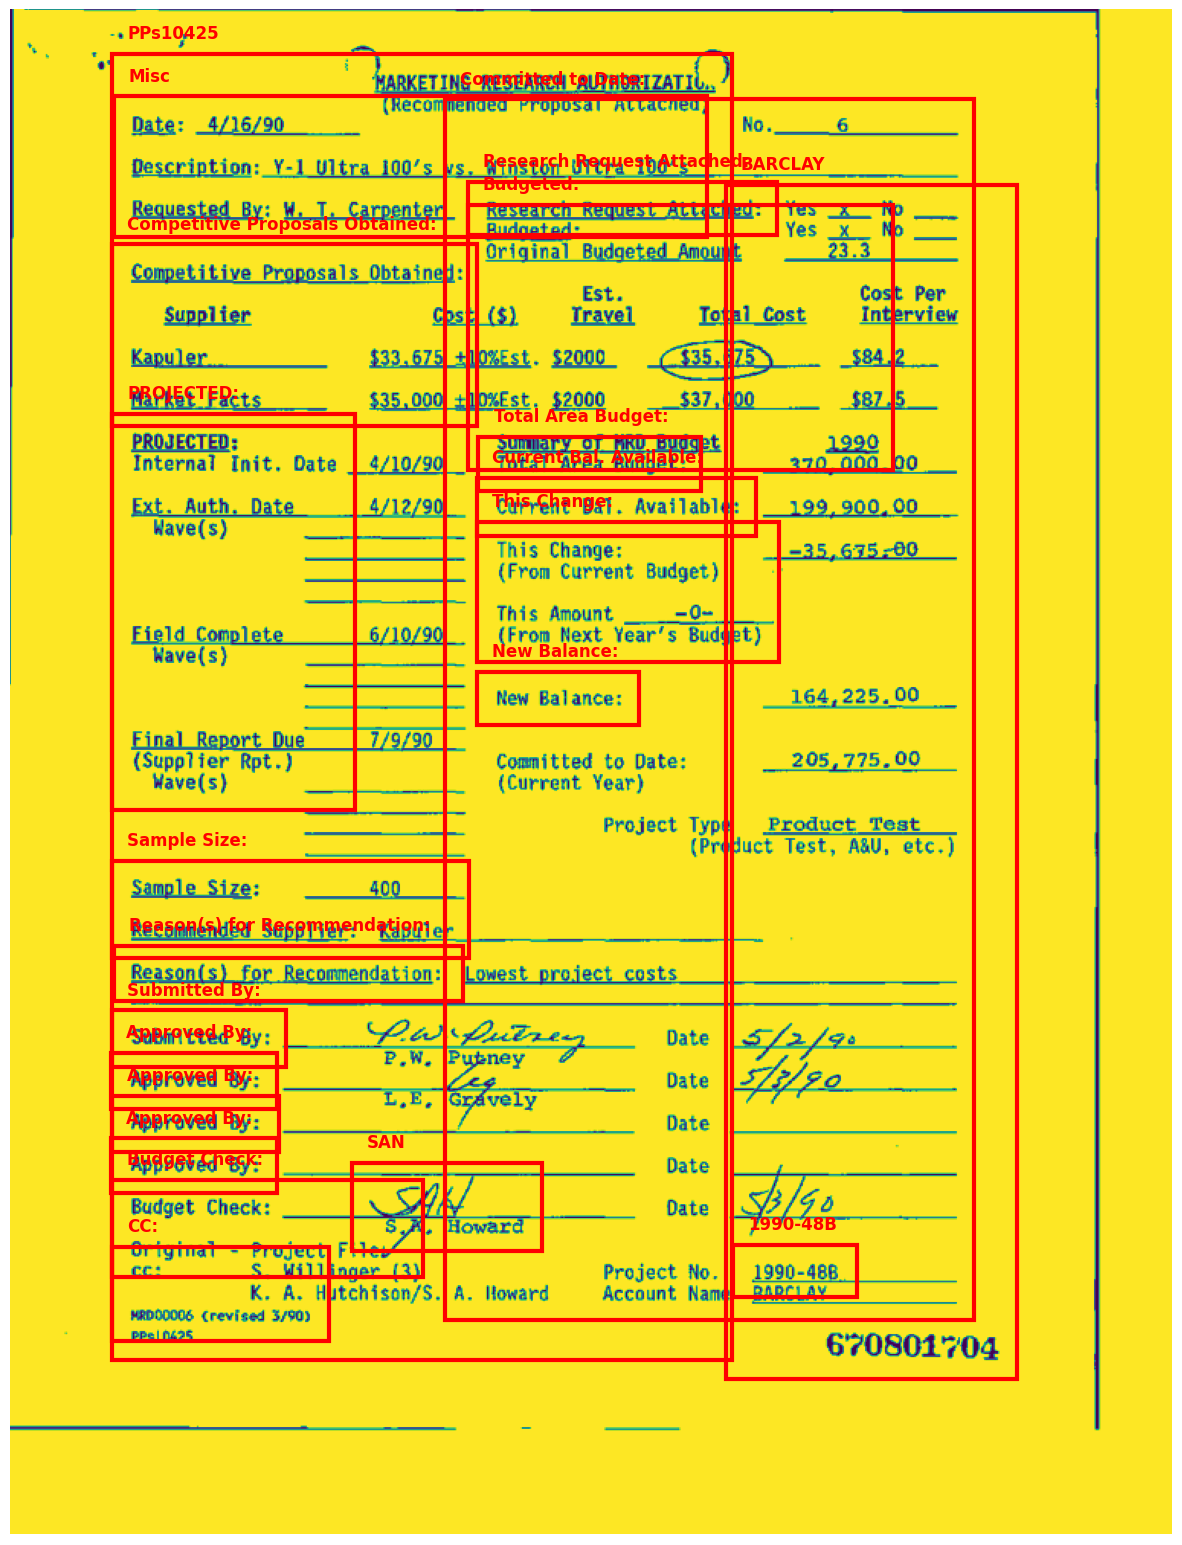


Showing hierarchy level 2:


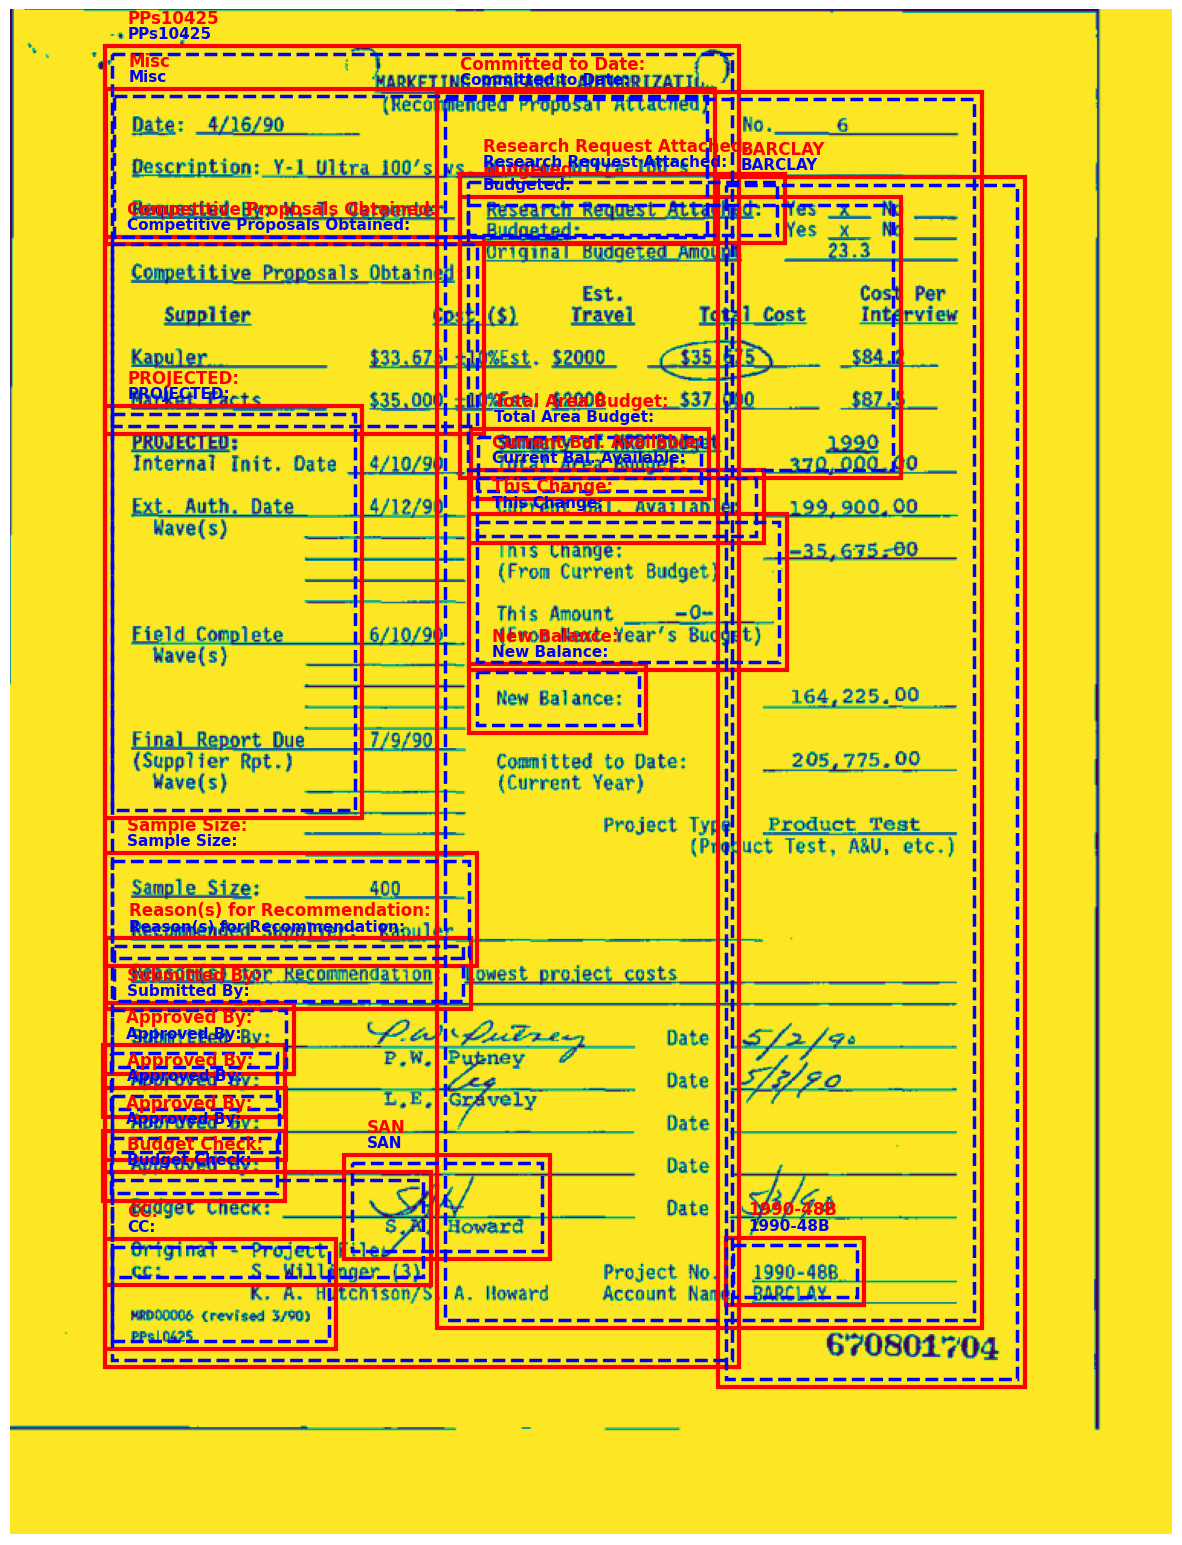

In [13]:
def plot_hierarchy_results(image_path, doc_structure, show_text=False, level=1):
    """
    Plot the hierarchical document structure over the image with section-level bounding boxes.
    
    Args:
        image_path (str): Path to the image file
        doc_structure (list): The hierarchical structure
        show_text (bool): Whether to show text labels
        level (int): How many levels of hierarchy to show (1: only main sections, 2: subsections, etc.)
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image
    import matplotlib.colors as mcolors
    
    # Load the image
    image = Image.open(image_path)
    
    # Create a plot
    fig, ax = plt.subplots(1, figsize=(15, 20))
    ax.imshow(image)
    
    # Define colors for different hierarchical levels
    level_colors = [
        'red',      # Level 1 (main sections)
        'blue',     # Level 2 (subsections)
        'green',    # Level 3
        'purple',   # Level 4
        'orange'    # Level 5
    ]
    
    def escape_text(text):
        """Helper function to escape special characters"""
        return text.replace('$', '\$').replace('%', '\%')
    
    def draw_section_box(points, level_idx, section_heading):
        if not points:
            return
            
        # Find the extremes to create section boundary
        min_x = min(p[0] for p in points)
        max_x = max(p[0] for p in points)
        min_y = min(p[1] for p in points)
        max_y = max(p[1] for p in points)
        
        # Add padding (larger padding for higher levels)
        padding = 5 * (level - level_idx + 1)
        section_coords = [
            (min_x - padding, min_y - padding),
            (max_x + padding, min_y - padding),
            (max_x + padding, max_y + padding),
            (min_x - padding, max_y + padding)
        ]
        
        # Draw section bounding box
        color = level_colors[level_idx % len(level_colors)]
        section_patch = patches.Polygon(
            section_coords, 
            closed=True,
            edgecolor=color,
            facecolor='none',
            linewidth=3 - level_idx * 0.5,  # Thicker lines for higher levels
            linestyle=['solid', 'dashed', 'dotted'][level_idx % 3]  # Different line styles per level
        )
        ax.add_patch(section_patch)
        
        # Add section heading text
        if show_text:
            ax.text(min_x, min_y - 10 * (level - level_idx + 1), 
                   escape_text(section_heading),
                   color=color,
                   fontsize=12 - level_idx,
                   weight='bold')
    
    # Plot each section level by level
    for current_level in range(level):
        for section in doc_structure:
            # Collect all points for this section
            section_points = []
            
            # Add heading polygon if available
            if 'polygon' in section:
                points = [(point['x'], point['y']) for point in section['polygon']]
                section_points.extend(points)
            
            # Add all line polygons
            for line in section['lines']:
                if 'polygon' in line:
                    points = [(point['x'], point['y']) for point in line['polygon']]
                    section_points.extend(points)
            
            # Draw the section box for this level
            draw_section_box(section_points, current_level, section['heading'])
    
    # Set the axis limits to fit the image
    ax.set_xlim([0, image.width])
    ax.set_ylim([image.height, 0])
    ax.axis('off')
    
    plt.show()

# Test with different levels
for level in [1, 2]:  # You can test with different levels
    print(f"\nShowing hierarchy level {level}:")
    plot_hierarchy_results(image_path, doc_structure, show_text=True, level=level)